In [1]:
import socket
import sys
import os
import time
import importlib
from pathlib import Path
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "../../src"))) #use this to be able to import local packages
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "../../../src"))) #use this to be able to import local packages
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "../src"))) #use this to be able to import local packages
import numpy as np
import pandas as pd
import pickle
import pyarrow.parquet as pq
from utils.openkarst_network import OpenKarstNetwork as OKN
import utils.conduits
importlib.reload(utils.conduits)
from utils.conduits import *
from utils.common import load_yaml, print_verbose, load_pickle, write_pickle
import openkarst
importlib.reload(openkarst)
from openkarst.network_generation import compute_conduit_lengths
from openkarst.models import FlowSimulation
from openkarst.visualization.openkarst_viewer import launch_openkarst_viewer
from scripts.openkarst.extract_steady_state_conditions import extract_steady_state_conditions
from utils.spring import outlet_flow, write_outlet_flow
import seaborn as sns
import matplotlib.pyplot as plt


In [6]:
Q = pd.read_csv("C:/Users/huan1428/Documents/karst/discharge/Bear_Spring_HACH_WY25.csv")
Q = utils.common.convert_df_to_datetime(Q, 'Datetime')
Q['m3/s'] = Q['Provisional Flow (cfs)'] * 0.0283168

(np.float64(20259.0), np.float64(20279.0))

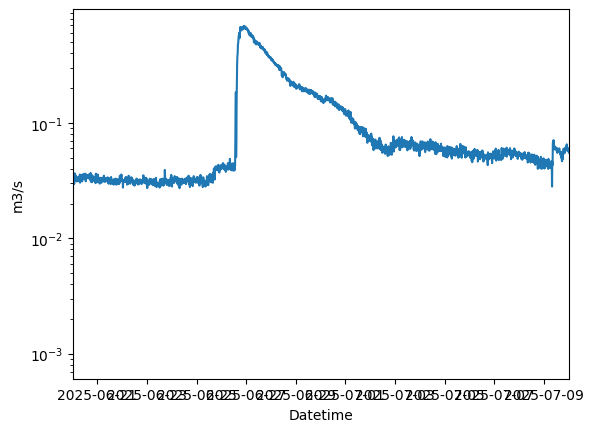

In [16]:
sns.lineplot(data = Q, x = 'Datetime', y = 'm3/s')
plt.yscale('log')
plt.xlim(pd.Timestamp('2025-06-20'), pd.Timestamp('2025-07-10'))

In [17]:
P = pd.read_csv("c:/Users/huan1428/Documents/karst/precipitation/rochester_intl_airport/precip_WY25_RIA_cleaned.csv")

In [19]:
P['PRCP']

0      0.00
1      0.00
2      0.01
3      0.00
4      0.00
       ... 
361    0.00
362    0.00
363    0.00
364    0.00
365    0.00
Name: PRCP, Length: 366, dtype: float64